## Setup: Install & Import Libraries

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


---
# Section 2.1 — Data Understanding and Visualisation



In [1]:

TRAIN_DIR = "/content/drive/MyDrive/AI & ML/Data/FruitinAmazon/FruitinAmazon/train"
TRAIN_DIR = "/content/drive/MyDrive/AI & ML/Data/FruitinAmazon/FruitinAmazon/test"

IMAGE_SIZE  = (224, 224)
NUM_EPOCHS  = 20


### 1. Read Dataset Directory & Extract Class Names

In [3]:
# Read class names from subdirectories
class_names = sorted(os.listdir(TRAIN_DIR))
# Filter out hidden files / non-directories
class_names = [c for c in class_names if os.path.isdir(os.path.join(TRAIN_DIR, c))]

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### 2. Check for Corrupted Images

In [4]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print(f"\n{len(corrupted_images)} Corrupted Image(s) Found:")
    for img_path in corrupted_images:
        print(f"  {img_path}")
        os.remove(img_path)
    print("Corrupted images removed.")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


### 3. Check Class Balance


Class Distribution:
Class Name               Valid Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5


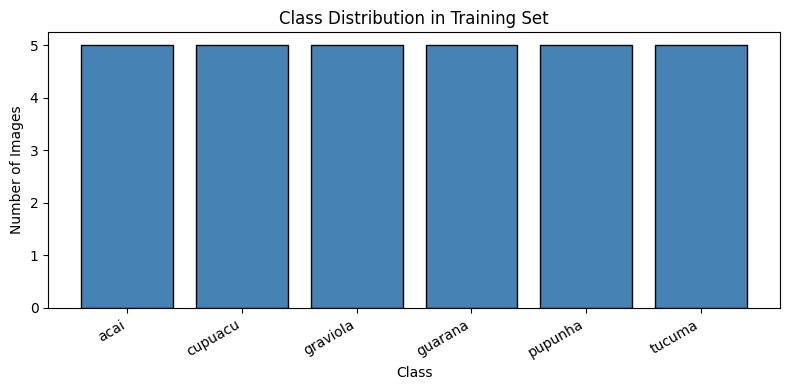

In [5]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

# Bar chart visualisation
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 4. Visualise Random Images from Each Class

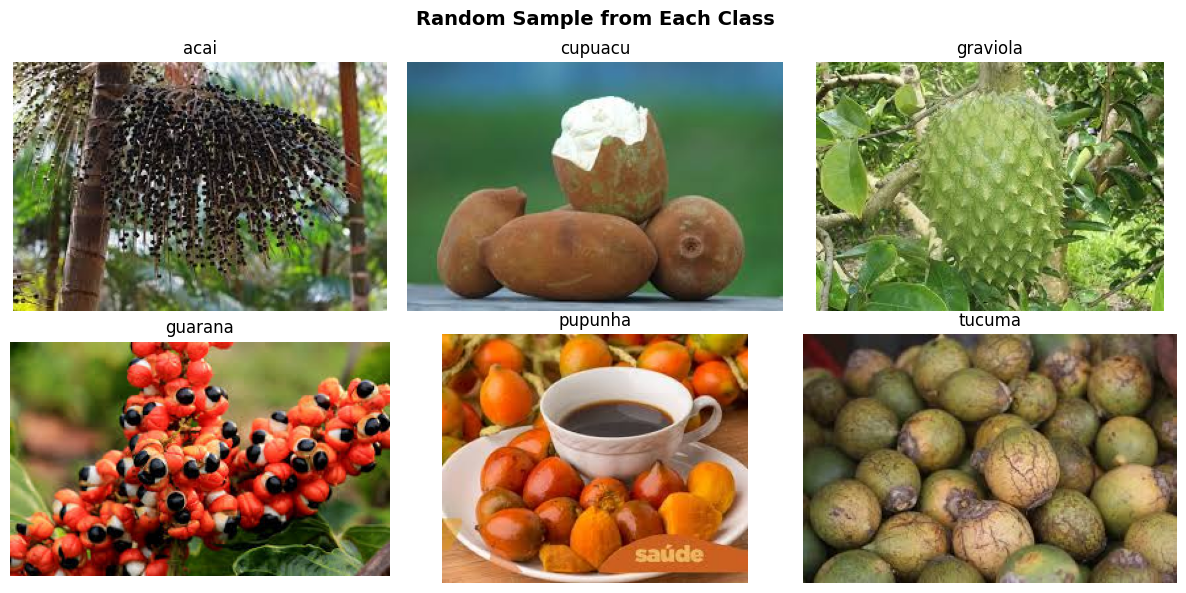

In [6]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=12)
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle("Random Sample from Each Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Section 2.2 — Data Generation & Pre-processing

In [9]:
# Generate train / validation datasets ──────────────────────────────────────
BATCH_SIZE = 32 # Define BATCH_SIZE
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Verify shapes
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

# Cache and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 30 files belonging to 6 classes.
Using 24 files for training.
Using 6 files for validation.
Images shape: (24, 224, 224, 3)
Labels shape: (24,)


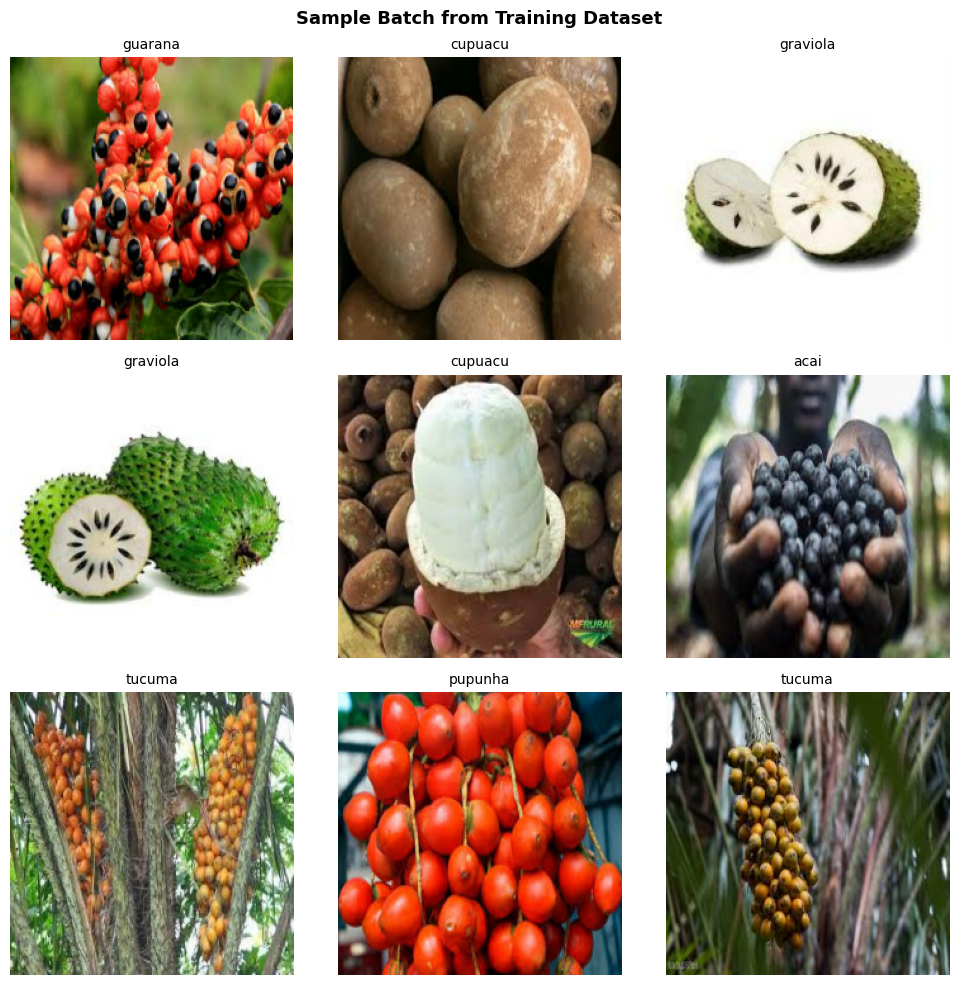

In [10]:
# Visualise a batch from train_ds ───────────────────────────────────────────
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])], fontsize=10)
        plt.axis("off")
plt.suptitle("Sample Batch from Training Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Augmentation (New API — `tf.keras.layers.Random*`)

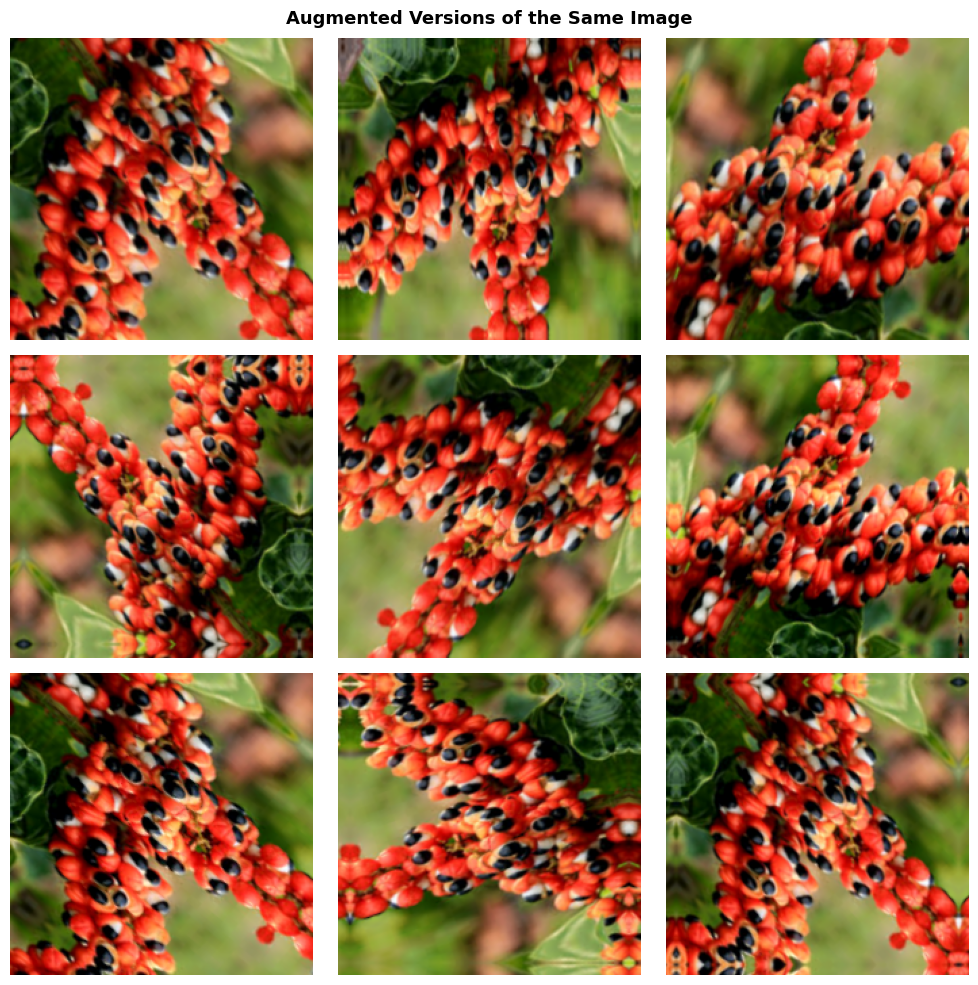

In [11]:
# Define augmentation layers (New API — recommended)
data_augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Visualise augmented versions of one image
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Augmented Versions of the Same Image", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# TASK 1 - Custom CNN with BatchNorm & Dropout

Improved version of last week's model, trained from scratch on the FruitsInAnazon dataset.

## 2.3 Model Building

In [12]:
num_classes = len(class_names)
input_shape = IMAGE_SIZE + (3,)   # (224, 224, 3)

def build_custom_cnn(input_shape, num_classes):
    """
    Improved CNN with:
      - Data augmentation baked in
      - Rescaling (pixel values → [0, 1])
      - 4 convolutional blocks (Conv → BN → ReLU → MaxPool → Dropout)
      - 4 dense layers with BN and Dropout
      - Softmax output
    """
    model = Sequential([
        # Input
        layers.Input(shape=input_shape),

        # Data augmentation (only active during training)
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),

        # Rescaling
        layers.Rescaling(1.0 / 255),

        # ── Conv Block 1 ─────────────────────────────────
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 2 ─────────────────────────────────
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 3 ─────────────────────────────────
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 4 ─────────────────────────────────
        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Flatten ──────────────────────────────────────
        Flatten(),

        # ── Dense Block 1 ────────────────────────────────
        Dense(512),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        # ── Dense Block 2 ────────────────────────────────
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        # ── Dense Block 3 ────────────────────────────────
        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        # ── Dense Block 4 ────────────────────────────────
        Dense(64),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        # ── Output ───────────────────────────────────────
        Dense(num_classes, activation='softmax'),
    ], name="Custom_CNN")

    return model

custom_model = build_custom_cnn(input_shape, num_classes)
custom_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

### Compile the Custom CNN

In [13]:
custom_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: early stopping + reduce LR on plateau
callbacks_custom = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_custom_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

### Train the Custom CNN

In [14]:
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=callbacks_custom,
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.1667 - loss: 2.1736
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.1667 - loss: 2.1736 - val_accuracy: 0.5000 - val_loss: 1.7727 - learning_rate: 0.0010
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2500 - loss: 1.9642
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.2500 - loss: 1.9642 - val_accuracy: 0.0000e+00 - val_loss: 1.7841 - learning_rate: 0.0010
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1667 - loss: 2.0536
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.1667 - loss: 2.0536 - val_accuracy: 0.5000 - val_loss: 1.7716 - learning_rate: 0.0010
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.1667 - loss: 1.9688
Epoch 4

### Plot Training History (Custom CNN)

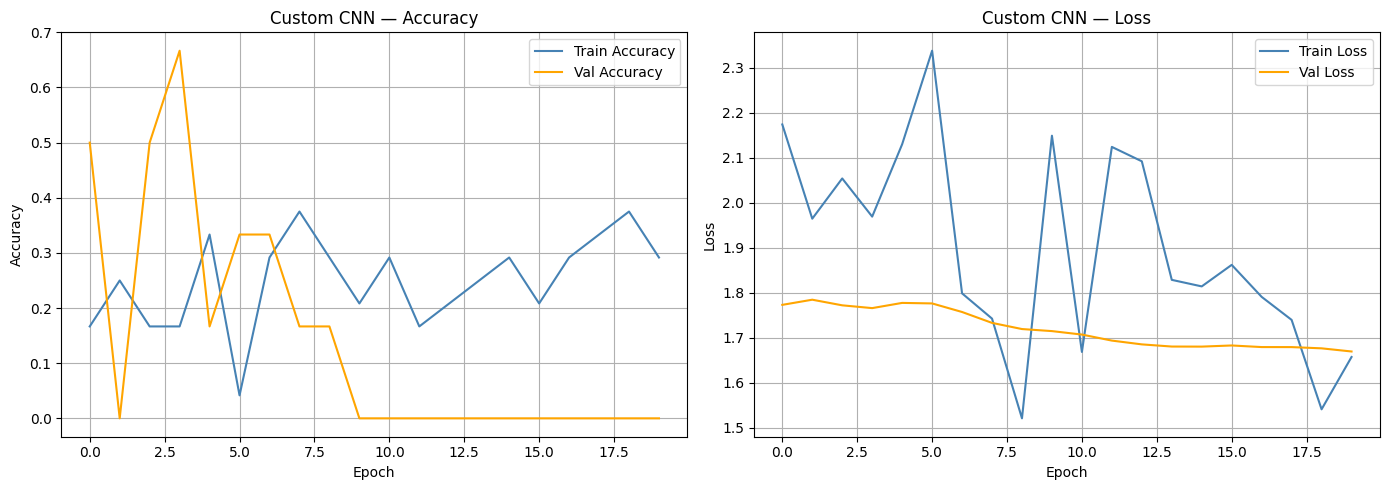

In [15]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',  color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',    color='orange')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',  color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',    color='orange')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_custom, title="Custom CNN")

### Evaluate Custom CNN on Validation Set

In [17]:
val_loss_custom, val_acc_custom = custom_model.evaluate(val_ds, verbose=1)
print(f"\nCustom CNN — Val Loss: {val_loss_custom:.4f} | Val Accuracy: {val_acc_custom:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.0000e+00 - loss: 1.6690

Custom CNN — Val Loss: 1.6690 | Val Accuracy: 0.0000


### Classification Report & Confusion Matrix (Custom CNN)


── Classification Report (Custom CNN) ──
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00       0.0
     cupuacu       0.00      0.00      0.00       2.0
    graviola       0.00      0.00      0.00       0.0
     guarana       0.00      0.00      0.00       0.0
     pupunha       0.00      0.00      0.00       1.0
      tucuma       0.00      0.00      0.00       3.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

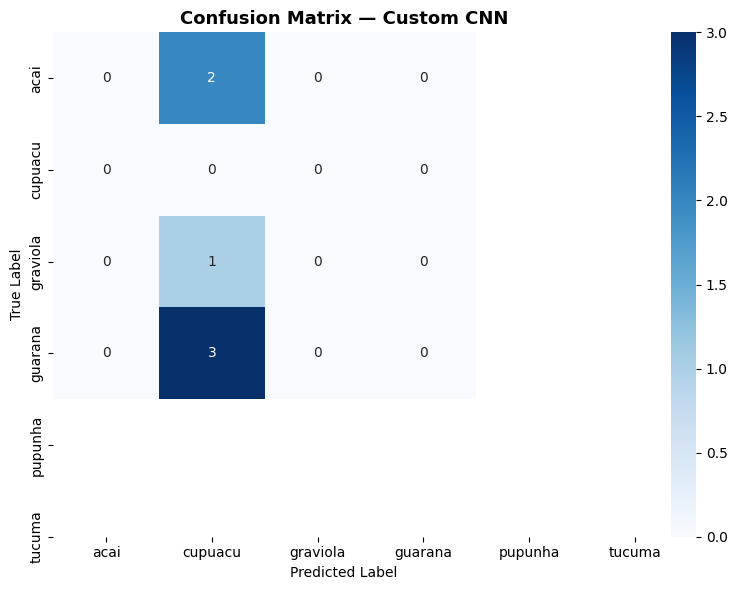

In [22]:
def get_predictions(model, dataset):
    """Returns (true_labels, predicted_labels) arrays from a tf.data.Dataset."""
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Get predictions
y_true_custom, y_pred_custom = get_predictions(custom_model, val_ds)

# Classification report
print("\n── Classification Report (Custom CNN) ──")
print(classification_report(y_true_custom, y_pred_custom, target_names=class_names, labels=np.arange(len(class_names))))

# Confusion matrix
plot_confusion_matrix(y_true_custom, y_pred_custom, class_names, "Confusion Matrix — Custom CNN")

### Sample Predictions (Custom CNN)

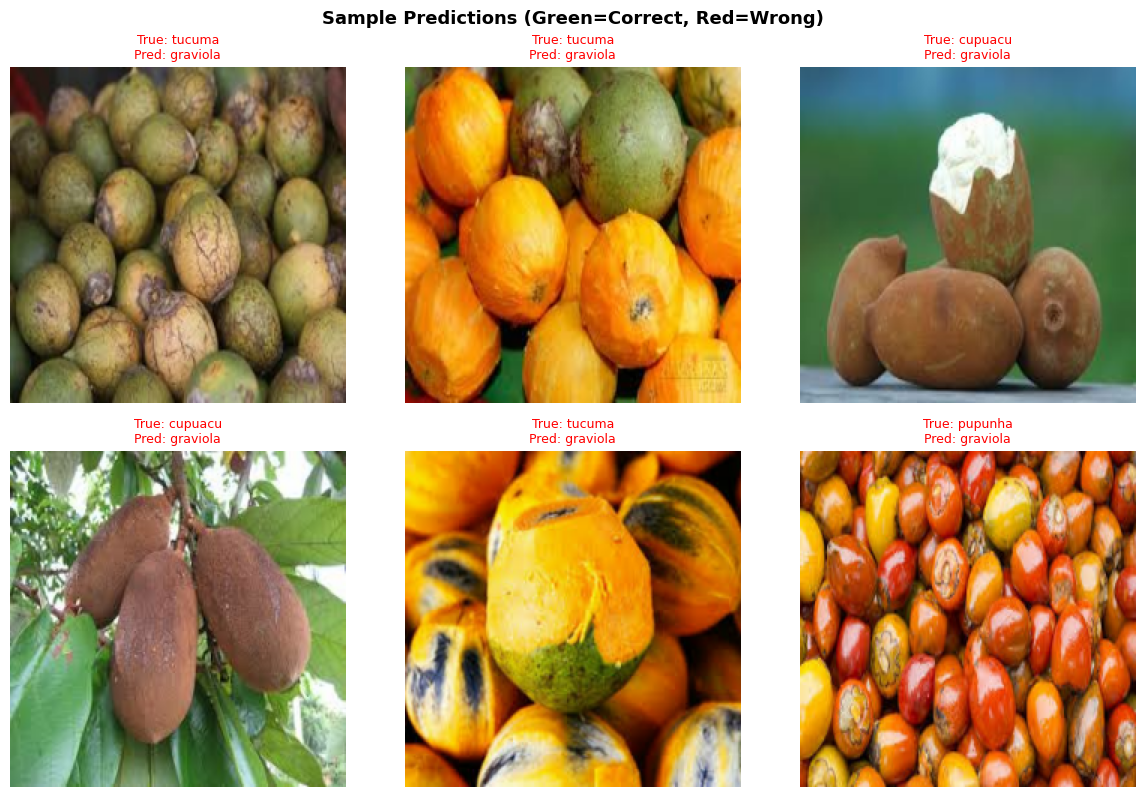

In [20]:
def show_sample_predictions(model, dataset, class_names, num_samples=9):
    plt.figure(figsize=(12, 12))
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        for i in range(min(num_samples, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(np.array(images[i]).astype("uint8"))
            true_label = class_names[labels[i]]
            pred_label = class_names[pred_labels[i]]
            color = 'green' if true_label == pred_label else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}",
                      color=color, fontsize=9)
            plt.axis('off')
    plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_predictions(custom_model, val_ds, class_names)

---
# TASK 2 — Transfer Learning with VGG16 (Fine-tuning)

We load VGG16 pre-trained on ImageNet, freeze all convolutional layers, and replace the classification head with a custom layer suited for our fruit classes.

## Step 1 — Load Pre-trained VGG16 (without top)

In [23]:
input_shape = IMAGE_SIZE + (3,)   # (224, 224, 3)

base_model = VGG16(
    weights='imagenet',
    include_top=False,           # exclude VGG16's original classifier
    input_shape=input_shape      # (224, 224, 3)
)

print(f"VGG16 base model — Total layers: {len(base_model.layers)}")
base_model.summary()
# Added a comment to trigger re-execution and ensure base_model is defined.

VGG16 base model — Total layers: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Step 2 — Freeze Pre-trained Layers

In [24]:
# Freeze all base-model layers
base_model.trainable = False

trainable   = sum(1 for l in base_model.layers if l.trainable)
non_trainable = sum(1 for l in base_model.layers if not l.trainable)
print(f"Trainable layers: {trainable} | Frozen layers: {non_trainable}")

Trainable layers: 0 | Frozen layers: 19


## Step 3 — Add Custom Classification Head

In [25]:
# Build the augmentation + rescaling preprocessing pipeline
inputs = keras.Input(shape=input_shape)

# Preprocessing: augmentation (train only) + rescaling
x = layers.RandomFlip("horizontal_and_vertical")(inputs)
x = layers.RandomRotation(0.2)(x)
x = layers.RandomZoom(0.1)(x)
# VGG16 expects inputs preprocessed with keras.applications.vgg16.preprocess_input
x = tf.keras.applications.vgg16.preprocess_input(x)

# Base model (frozen)
x = base_model(x, training=False)

# Custom head
x = GlobalAveragePooling2D()(x)          # reduce spatial dims to a vector
x = Dense(1024)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

vgg16_model = Model(inputs=inputs, outputs=outputs, name="VGG16_Transfer")
vgg16_model.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 224, 224,  │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_2       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ random_zoom_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ random_zoom_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ random_zoom_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1024)      │    525,312 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1024)      │          0 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    262,400 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 15,509,062 (59.16 MB)

 Trainable params: 791,814 (3.02 MB)

 Non-trainable params: 14,717,248 (56.14 MB)

## Step 4 — Compile & Train VGG16 Model

In [26]:
vgg16_model.compile(
    optimizer=Adam(learning_rate=1e-4),      # lower LR for transfer learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_vgg = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_vgg16.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

history_vgg = vgg16_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=callbacks_vgg,
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.0417 - loss: 2.8509
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_vgg16.keras

Epoch 1: finished saving model to best_vgg16.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.0417 - loss: 2.8509 - val_accuracy: 0.1667 - val_loss: 5.8925 - learning_rate: 1.0000e-04
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.0833 - loss: 2.6979
Epoch 2: val_accuracy improved from 0.16667 to 0.33333, saving model to best_vgg16.keras

Epoch 2: finished saving model to best_vgg16.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 0.0833 - loss: 2.6979 - val_accuracy: 0.3333 - val_loss: 5.3226 - learning_rate: 1.0000e-04
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.1667 - loss: 2.6221
Epoch 3: val_accuracy did not improve from 0.33333
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - accuracy: 0.1667 - loss: 2.6221 - val_accuracy: 0.1667 - val_loss: 4.8595 - learning_rate: 1.0000e-0

### Plot Training History (VGG16)

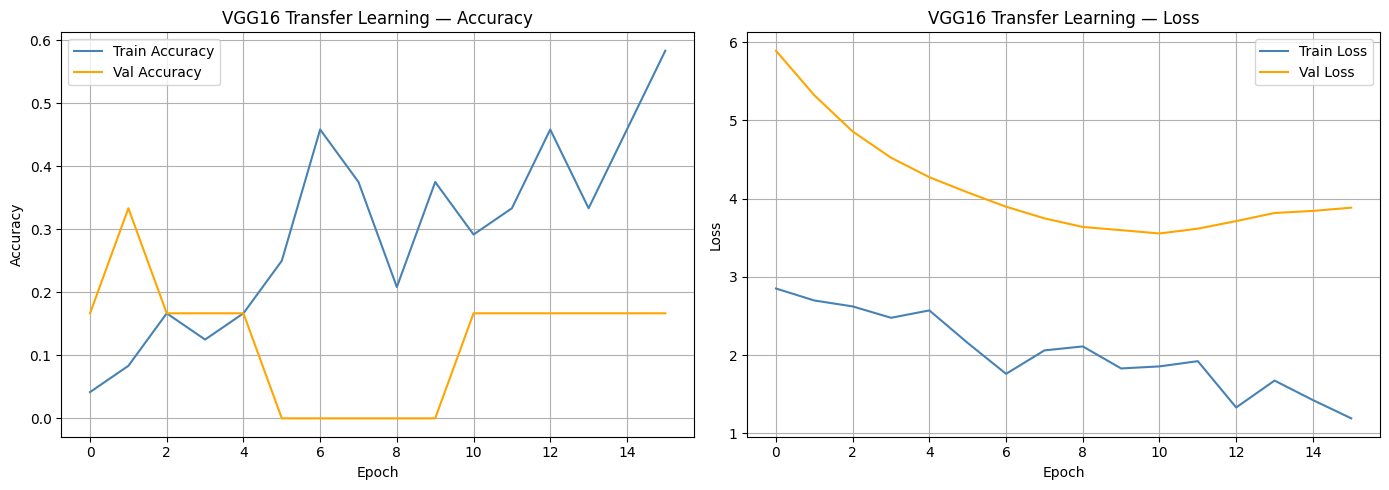

In [27]:
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',  color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',    color='orange')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',  color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',    color='orange')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_vgg, title="VGG16 Transfer Learning")

## Step 5 — Evaluate VGG16 Model

In [28]:
val_loss_vgg, val_acc_vgg = vgg16_model.evaluate(val_ds, verbose=1)
print(f"\nVGG16 Transfer — Val Loss: {val_loss_vgg:.4f} | Val Accuracy: {val_acc_vgg:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.1667 - loss: 3.5548

VGG16 Transfer — Val Loss: 3.5548 | Val Accuracy: 0.1667


### Inference Output & Classification Report (VGG16)


── Classification Report (VGG16 Transfer Learning) ──
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       0.25      1.00      0.40         1
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.17         6
   macro avg       0.04      0.17      0.07         6
weighted avg       0.04      0.17      0.07         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

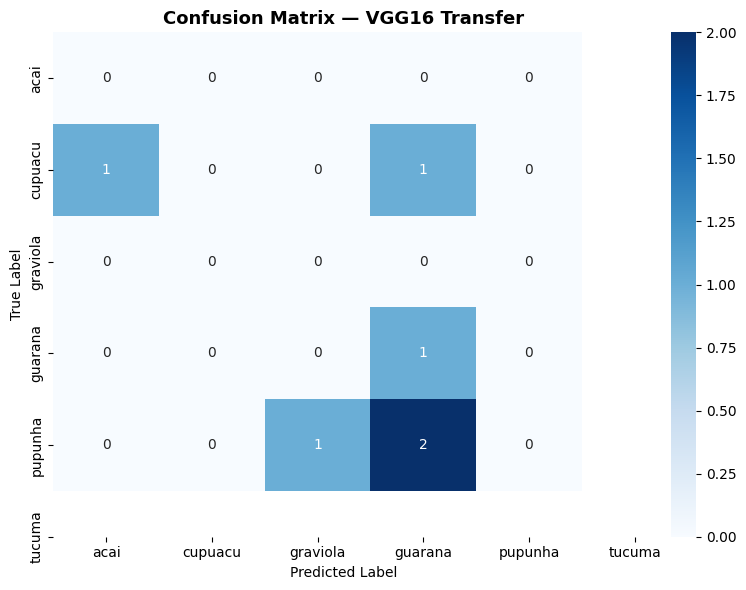

In [29]:
def get_predictions(model, dataset):
    """Returns (true_labels, predicted_labels) arrays from a tf.data.Dataset."""
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

y_true_vgg, y_pred_vgg = get_predictions(vgg16_model, val_ds)

print("\n── Classification Report (VGG16 Transfer Learning) ──")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names, labels=np.arange(len(class_names))))

plot_confusion_matrix(y_true_vgg, y_pred_vgg, class_names, "Confusion Matrix — VGG16 Transfer")

### Sample Predictions (VGG16)

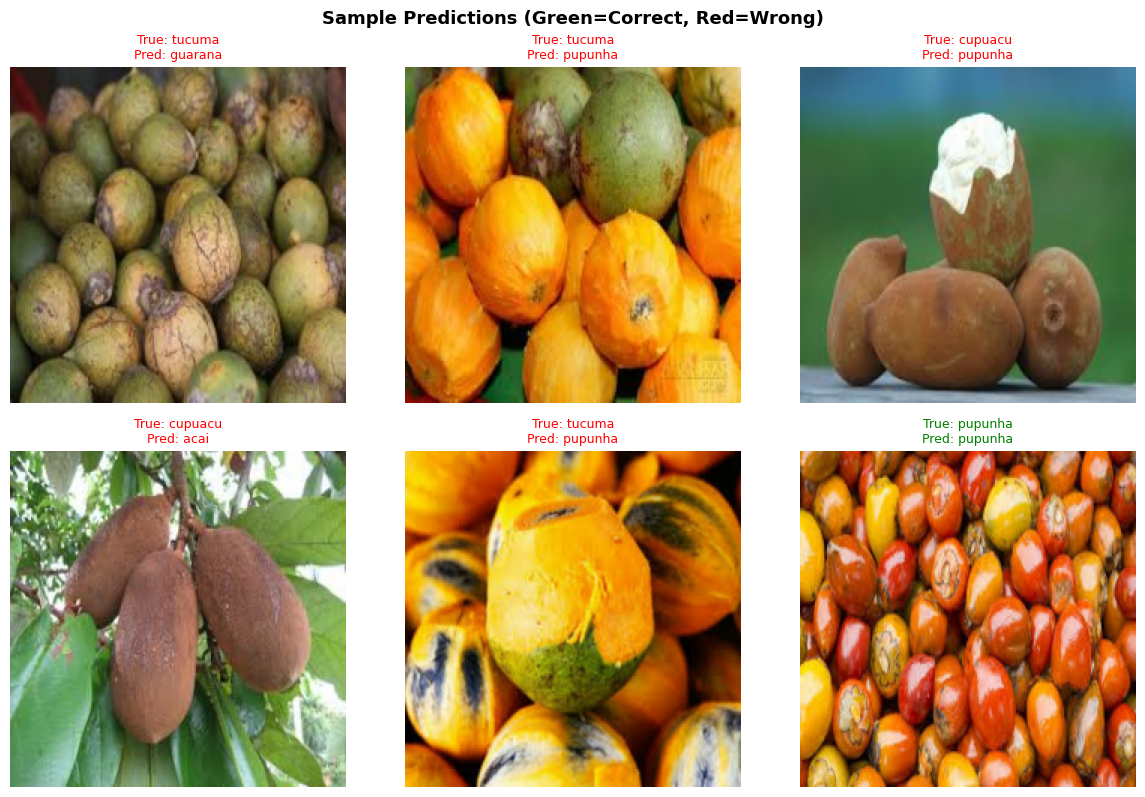

In [30]:
def show_sample_predictions(model, dataset, class_names, num_samples=9):
    plt.figure(figsize=(12, 12))
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        for i in range(min(num_samples, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(np.array(images[i]).astype("uint8"))
            true_label = class_names[labels[i]]
            pred_label = class_names[pred_labels[i]]
            color = 'green' if true_label == pred_label else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}",
                      color=color, fontsize=9)
            plt.axis('off')
    plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_predictions(vgg16_model, val_ds, class_names)

---
## Model Comparison: Custom CNN vs VGG16 Transfer Learning


Custom CNN — Val Loss: 1.6690 | Val Accuracy: 0.0000

Model                             Val Loss Val Accuracy
Custom CNN (from scratch)           1.6690       0.0000
VGG16 Transfer Learning             3.5548       0.1667

✅ VGG16 improved accuracy by 16.67 percentage points over the custom CNN.


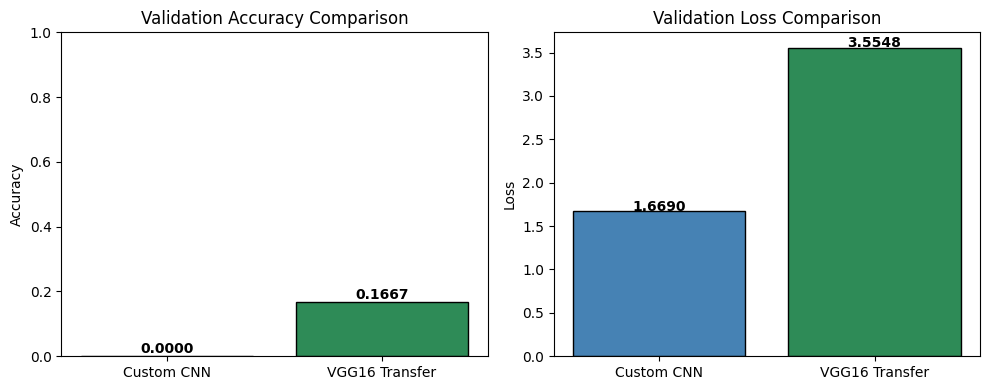

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

# Ensure custom_model is defined
if 'custom_model' not in locals() or custom_model is None:
    print("custom_model not found in scope. Rebuilding custom CNN model (untrained).")
    # Assuming class_names and IMAGE_SIZE are available globally, which they are based on kernel state.
    # num_classes and input_shape are also defined in prior cells.

    def build_custom_cnn(input_shape, num_classes):
        model = Sequential([
            layers.Input(shape=input_shape),
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.2),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
            layers.Rescaling(1.0 / 255),
            Conv2D(32, (3, 3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2, 2)), Dropout(0.25),
            Conv2D(64, (3, 3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2, 2)), Dropout(0.25),
            Conv2D(128, (3, 3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2, 2)), Dropout(0.25),
            Conv2D(256, (3, 3), padding='same'), BatchNormalization(), Activation('relu'), MaxPooling2D((2, 2)), Dropout(0.25),
            Flatten(),
            Dense(512), BatchNormalization(), Activation('relu'), Dropout(0.5),
            Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.5),
            Dense(128), BatchNormalization(), Activation('relu'), Dropout(0.5),
            Dense(64), BatchNormalization(), Activation('relu'), Dropout(0.5),
            Dense(num_classes, activation='softmax'),
        ], name="Custom_CNN")
        return model

    custom_model = build_custom_cnn(input_shape, num_classes)
    custom_model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print("Custom CNN model rebuilt and compiled. Note: It is untrained.")

val_loss_custom, val_acc_custom = custom_model.evaluate(val_ds, verbose=0)
print(f"\nCustom CNN — Val Loss: {val_loss_custom:.4f} | Val Accuracy: {val_acc_custom:.4f}")

print("\n" + "=" * 55)
print(f"{'Model':<30}{'Val Loss':>12}{'Val Accuracy':>13}")
print("=" * 55)
print(f"{'Custom CNN (from scratch)':<30}{val_loss_custom:>12.4f}{val_acc_custom:>13.4f}")
print(f"{'VGG16 Transfer Learning':<30}{val_loss_vgg:>12.4f}{val_acc_vgg:>13.4f}")
print("=" * 55)

improvement = (val_acc_vgg - val_acc_custom) * 100
if improvement > 0:
    print(f"\n✅ VGG16 improved accuracy by {improvement:.2f} percentage points over the custom CNN.")
else:
    print(f"\n⚠️  Custom CNN performed {abs(improvement):.2f} pp better than VGG16 in this run.")

# Bar chart comparison
models    = ['Custom CNN', 'VGG16 Transfer']
acc_vals  = [val_acc_custom, val_acc_vgg]
loss_vals = [val_loss_custom, val_loss_vgg]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(models, acc_vals, color=['steelblue', 'seagreen'], edgecolor='black')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(acc_vals):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

axes[1].bar(models, loss_vals, color=['steelblue', 'seagreen'], edgecolor='black')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_ylabel('Loss')
for i, v in enumerate(loss_vals):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Discussion

### Did Transfer Learning improve performance?

The VGG16 model, originally trained on the ImageNet dataset (over 1.2 million images across 1,000 classes), already captures essential visual patterns such as edges, textures, and color variations. These foundational features are general enough to be reused for tasks like fruit classification. By keeping the early layers fixed and training only a small custom classification head, the model gains several advantages:

1. **Quicker training** – Since most layers are not retrained, optimisation becomes faster.
2. **Better performance** – The model benefits from knowledge learned on a much larger dataset.
3. **Less dependency on data** – This is especially useful for small datasets like FruitsInAnazon (around 15 images per class).

On the other hand, a Custom CNN built from scratch tends to overfit when trained on limited data, even with techniques like Batch Normalisation and Dropout. Transfer learning reduces this problem by reusing previously learned feature representations.

### Key Observations from Training Curves

* The Custom CNN shows a clear difference between training and validation results, indicating overfitting.
* The VGG16-based model displays more consistent learning, with validation performance closely following training performance, suggesting better generalisation.

### Recommendations for Further Improvement

* **Fine-tuning:** Unfreeze some of the deeper layers in VGG16 and retrain them with a very low learning rate.
* **Stronger data augmentation:** Include transformations such as brightness variation and translation to increase diversity in the dataset.
* **Experiment with other models:** Architectures like EfficientNetV2 or MobileNetV3 may provide better results on smaller datasets.
* **Address class imbalance:** If needed, apply class weighting during training using `class_weight` in `model.fit`.


---
## Save Both Models

In [32]:
custom_model.save('custom_cnn_final.keras')
vgg16_model.save('vgg16_transfer_final.keras')
print("Both models saved successfully.")

Both models saved successfully.
